In [1]:
# Import everything we need later
!pip install ucimlrepo tensorflow seaborn

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA, KernelPCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# saving everything to colab first
SAVE_DIR = "./ionosphere_fyp_outputs"

folders = [
    SAVE_DIR,
    f"{SAVE_DIR}/data",
    f"{SAVE_DIR}/figures",
    f"{SAVE_DIR}/models",
    f"{SAVE_DIR}/results",
    f"{SAVE_DIR}/embeddings"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [3]:
# Loading the dataset
from ucimlrepo import fetch_ucirepo

ionosphere = fetch_ucirepo(id=52)

X_raw = ionosphere.data.features.copy()
y_raw = ionosphere.data.targets.copy()

df = X_raw.copy()
df["label"] = y_raw.iloc[:, 0]

df.columns = [f"feature_{i}" for i in range(34)] + ["label"]
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,label
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [4]:
# Save the raw data
df.to_csv(f"{SAVE_DIR}/data/ionosphere_raw.csv", index=False)
print("Raw dataset saved.")

Raw dataset saved.


### Explore and visualize the data

In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["label"].value_counts())
print("\nSummary statistics:\n", df.describe())

Shape: (351, 35)

Data types:
 feature_0       int64
feature_1       int64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
feature_22    float64
feature_23    float64
feature_24    float64
feature_25    float64
feature_26    float64
feature_27    float64
feature_28    float64
feature_29    float64
feature_30    float64
feature_31    float64
feature_32    float64
feature_33    float64
label          object
dtype: object

Missing values:
 feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature

In [6]:
with open(f"{SAVE_DIR}/results/data_summary.txt", "w") as f:
    f.write(f"Shape: {df.shape}\n\n")
    f.write("Missing values:\n")
    f.write(str(df.isnull().sum()))
    f.write("\n\nClass distribution:\n")
    f.write(str(df["label"].value_counts()))
    f.write("\n\nSummary statistics:\n")
    f.write(str(df.describe()))

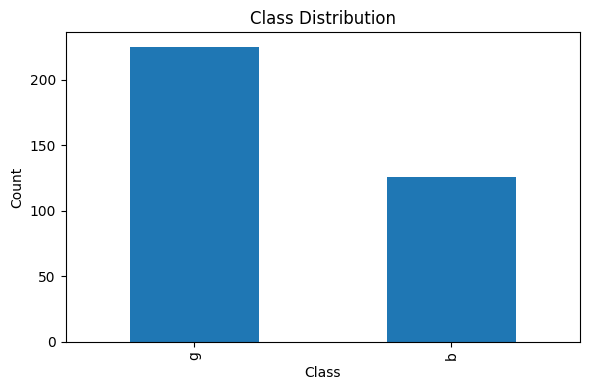

In [7]:
plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/class_distribution.png", dpi=300)
plt.show()

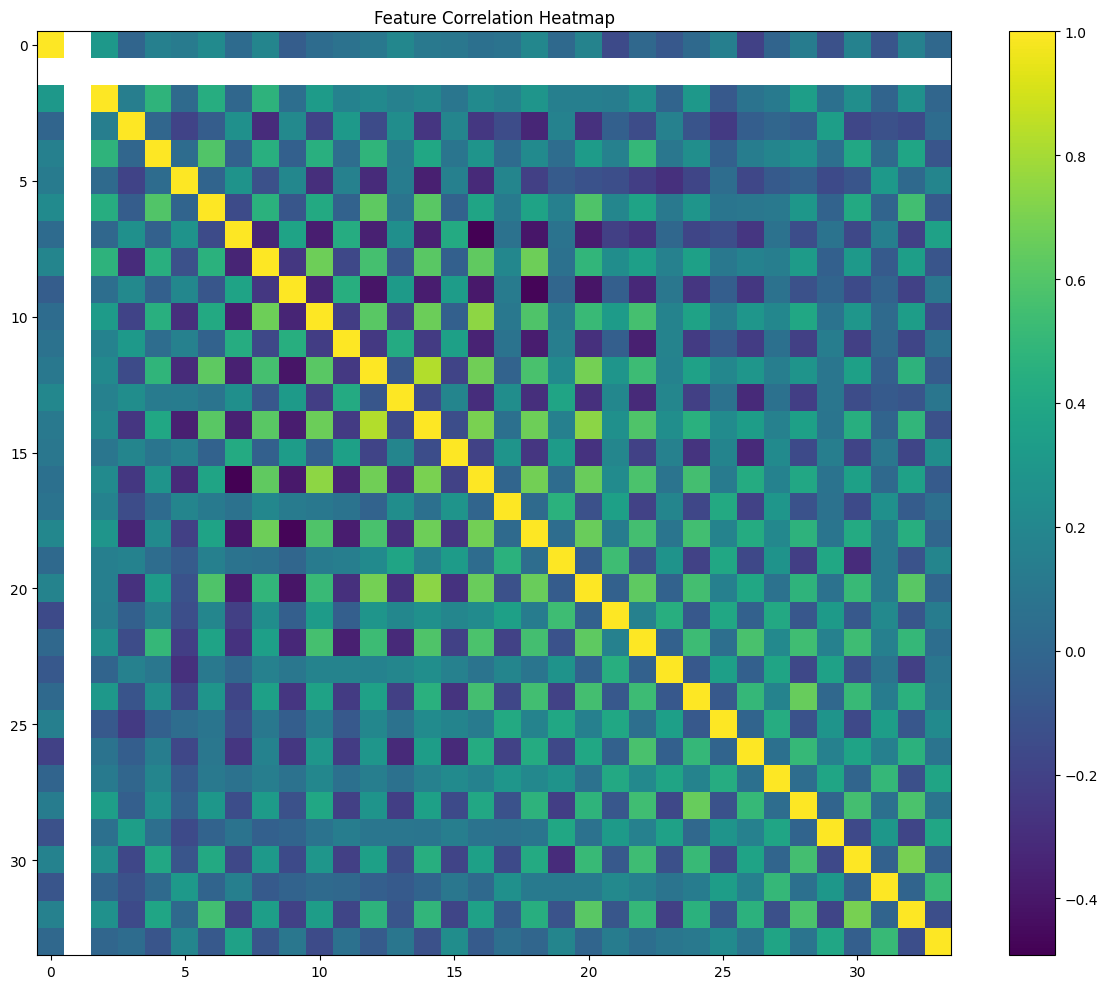

In [8]:
plt.figure(figsize=(12, 10))
corr = df.drop(columns=["label"]).corr()
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/correlation_heatmap.png", dpi=300)
plt.show()

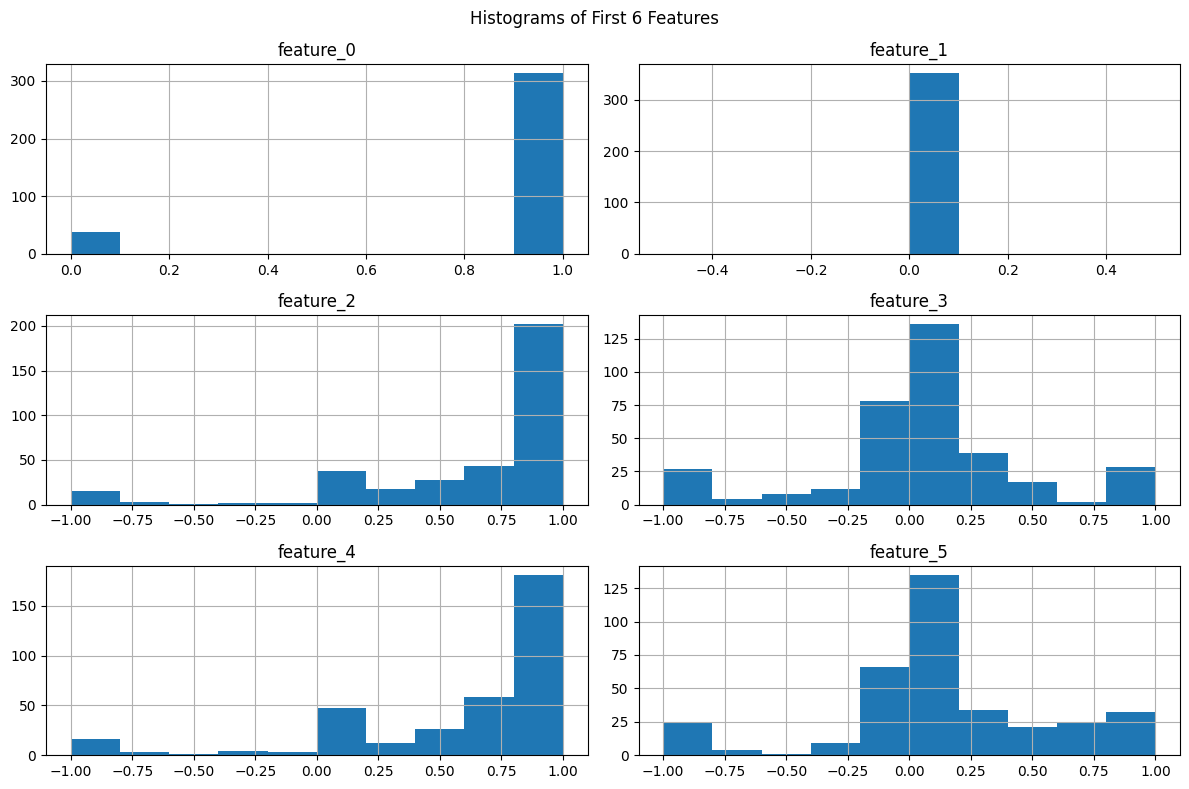

In [9]:
df.drop(columns=["label"]).iloc[:, :6].hist(figsize=(12, 8))
plt.suptitle("Histograms of First 6 Features")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/feature_histograms.png", dpi=300)
plt.show()

###Prepare the data for training - Preprocessing

In [10]:
X = df.drop(columns=["label"]).copy()
y = df["label"].map({"g": 1, "b": 0}).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save processed arrays
np.save(f"{SAVE_DIR}/data/X_train_scaled.npy", X_train_scaled)
np.save(f"{SAVE_DIR}/data/X_test_scaled.npy", X_test_scaled)
np.save(f"{SAVE_DIR}/data/y_train.npy", y_train.to_numpy())
np.save(f"{SAVE_DIR}/data/y_test.npy", y_test.to_numpy())

print("Preprocessing complete.")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Preprocessing complete.
Train shape: (280, 34)
Test shape: (71, 34)


### Visualize the scaled data with PCA and t-SNE

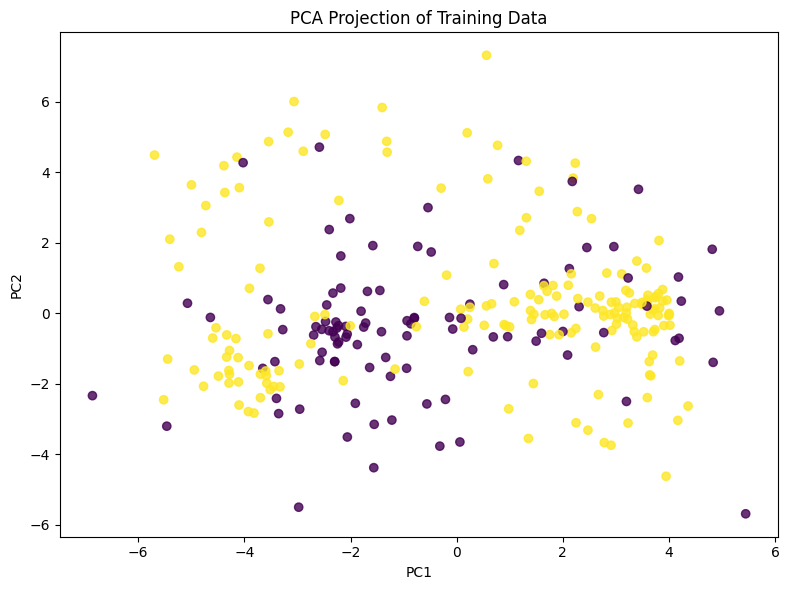

In [11]:
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    alpha=0.8
)
plt.title("PCA Projection of Training Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/pca_2d_train.png", dpi=300)
plt.show()

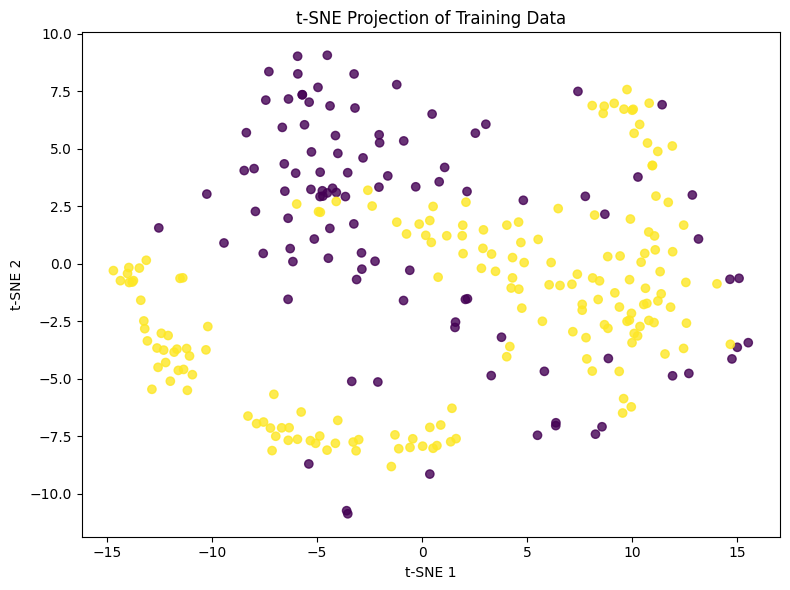

In [12]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_train_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_tsne[:, 0],
    X_train_tsne[:, 1],
    c=y_train,
    alpha=0.8
)
plt.title("t-SNE Projection of Training Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/tsne_2d_train.png", dpi=300)
plt.show()

### Create evaluation helpers for training on all models

In [13]:
def evaluate_model(model, X_train_data, X_test_data, y_train, y_test, model_name):
    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

    print(f"\n{model_name}")
    print(results)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/figures/confusion_matrix_{model_name.replace(' ', '_')}.png", dpi=300)
    plt.show()

    return results

1-Linear SVM


Linear SVM
{'Model': 'Linear SVM', 'Accuracy': 0.8873239436619719, 'Precision': 0.8958333333333334, 'Recall': 0.9347826086956522, 'F1': 0.9148936170212766}

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.80      0.83        25
           1       0.90      0.93      0.91        46

    accuracy                           0.89        71
   macro avg       0.88      0.87      0.87        71
weighted avg       0.89      0.89      0.89        71



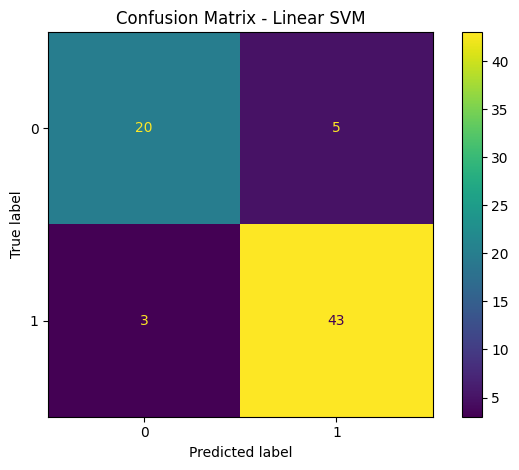

In [14]:
linear_svm = SVC(kernel="linear", random_state=42)
linear_results = evaluate_model(
    linear_svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Linear SVM"
)

RBF Model


RBF SVM
{'Model': 'RBF SVM', 'Accuracy': 0.9577464788732394, 'Precision': 0.9574468085106383, 'Recall': 0.9782608695652174, 'F1': 0.967741935483871}

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        25
           1       0.96      0.98      0.97        46

    accuracy                           0.96        71
   macro avg       0.96      0.95      0.95        71
weighted avg       0.96      0.96      0.96        71



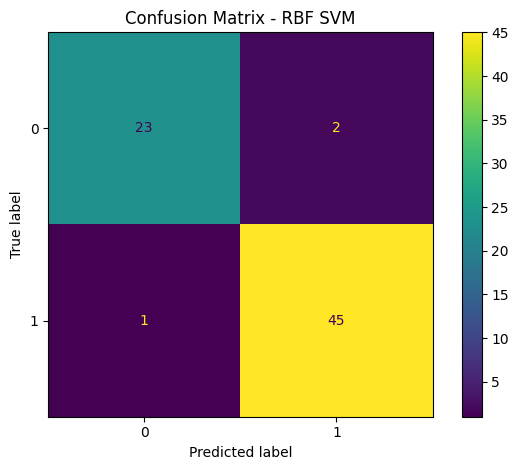

In [15]:
rbf_svm = SVC(kernel="rbf", random_state=42)
rbf_results = evaluate_model(
    rbf_svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "RBF SVM"
)

PCA embedding + Linear SVM

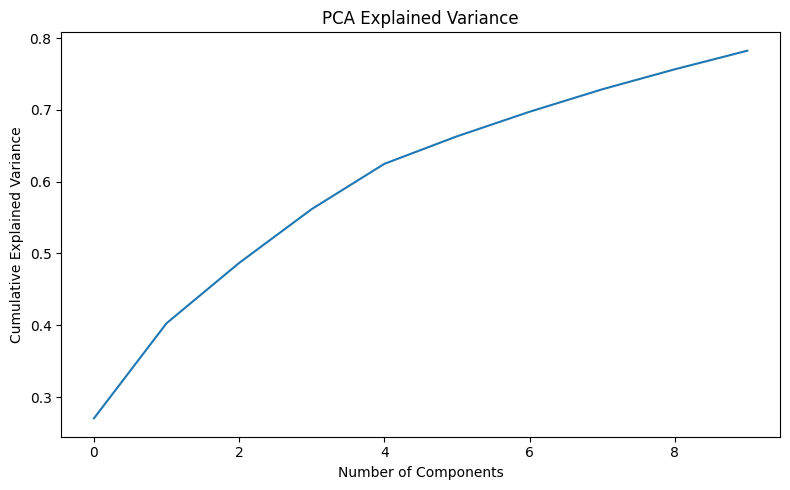


PCA + Linear SVM
{'Model': 'PCA + Linear SVM', 'Accuracy': 0.9295774647887324, 'Precision': 0.9019607843137255, 'Recall': 1.0, 'F1': 0.9484536082474226}

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        25
           1       0.90      1.00      0.95        46

    accuracy                           0.93        71
   macro avg       0.95      0.90      0.92        71
weighted avg       0.94      0.93      0.93        71



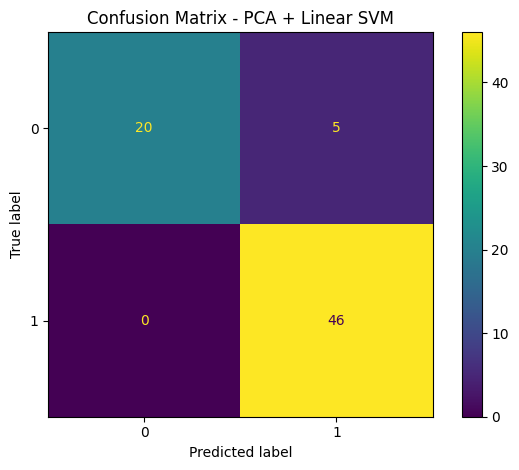

In [16]:
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

np.save(f"{SAVE_DIR}/embeddings/X_train_pca.npy", X_train_pca)
np.save(f"{SAVE_DIR}/embeddings/X_test_pca.npy", X_test_pca)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/pca_explained_variance.png", dpi=300)
plt.show()

pca_svm = SVC(kernel="linear", random_state=42)
pca_results = evaluate_model(
    pca_svm,
    X_train_pca,
    X_test_pca,
    y_train,
    y_test,
    "PCA + Linear SVM"
)

Kernel PCA embedding + Linear SVM


Kernel PCA + Linear SVM
{'Model': 'Kernel PCA + Linear SVM', 'Accuracy': 0.971830985915493, 'Precision': 0.9782608695652174, 'Recall': 0.9782608695652174, 'F1': 0.9782608695652174}

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        25
           1       0.98      0.98      0.98        46

    accuracy                           0.97        71
   macro avg       0.97      0.97      0.97        71
weighted avg       0.97      0.97      0.97        71



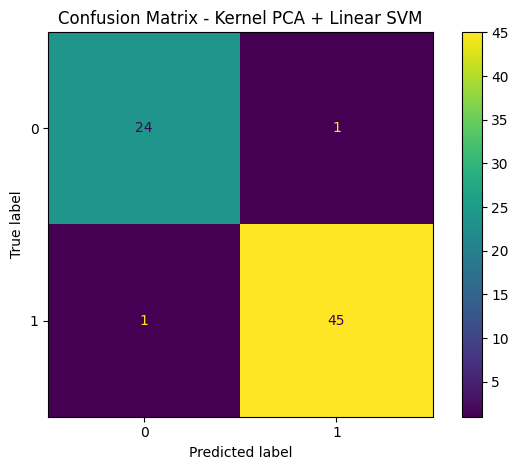

In [17]:
kpca = KernelPCA(n_components=10, kernel="rbf", random_state=42)
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

np.save(f"{SAVE_DIR}/embeddings/X_train_kpca.npy", X_train_kpca)
np.save(f"{SAVE_DIR}/embeddings/X_test_kpca.npy", X_test_kpca)

kpca_svm = SVC(kernel="linear", random_state=42)
kpca_results = evaluate_model(
    kpca_svm,
    X_train_kpca,
    X_test_kpca,
    y_train,
    y_test,
    "Kernel PCA + Linear SVM"
)

Polynomial Features embedding + Linear SVM

Polynomial feature shape: (280, 629)

Polynomial Features + Linear SVM
{'Model': 'Polynomial Features + Linear SVM', 'Accuracy': 0.9577464788732394, 'Precision': 0.9387755102040817, 'Recall': 1.0, 'F1': 0.968421052631579}

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        25
           1       0.94      1.00      0.97        46

    accuracy                           0.96        71
   macro avg       0.97      0.94      0.95        71
weighted avg       0.96      0.96      0.96        71



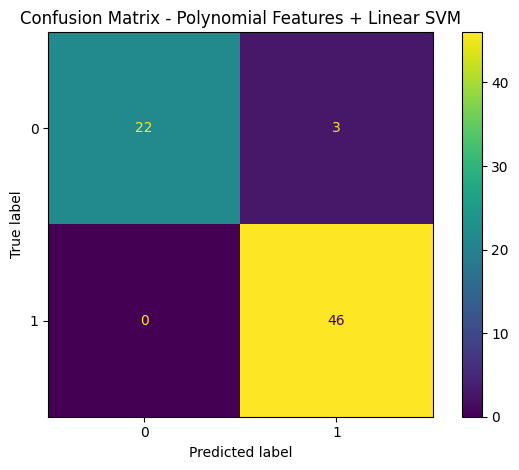

In [18]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

np.save(f"{SAVE_DIR}/embeddings/X_train_poly.npy", X_train_poly)
np.save(f"{SAVE_DIR}/embeddings/X_test_poly.npy", X_test_poly)

print("Polynomial feature shape:", X_train_poly.shape)

poly_svm = SVC(kernel="linear", random_state=42)
poly_results = evaluate_model(
    poly_svm,
    X_train_poly,
    X_test_poly,
    y_train,
    y_test,
    "Polynomial Features + Linear SVM"
)

Autoencoder embedding + Linear SVM

In [19]:
input_dim = X_train_scaled.shape[1]
embedding_dim = 8

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(embedding_dim, activation="relu", name="embedding_layer")(encoded)

decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=autoencoder.get_layer("embedding_layer").output)

autoencoder.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.9994 - val_loss: 1.0282
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9645 - val_loss: 1.0092
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9467 - val_loss: 0.9954
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9319 - val_loss: 0.9811
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9152 - val_loss: 0.9652
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8955 - val_loss: 0.9464
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8710 - val_loss: 0.9212
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8396 - val_loss: 0.8888
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8022 - val_loss: 0.8508
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7622 - val_loss: 0.8115
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7237 - val_loss: 0.7750
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.

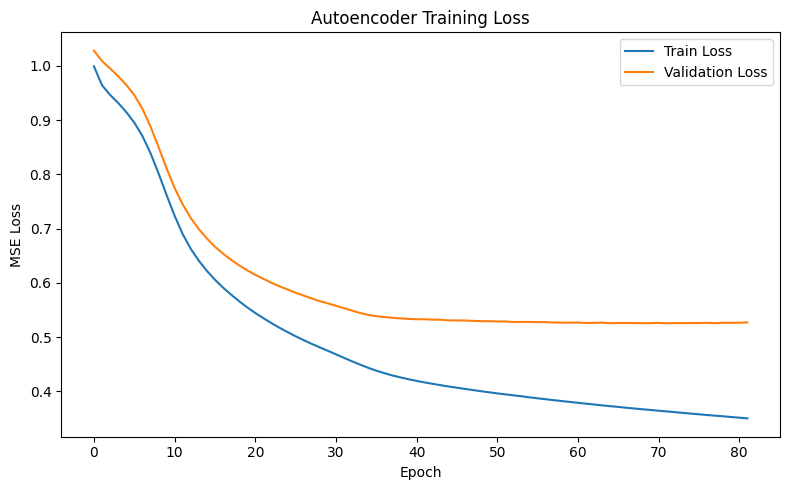

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/autoencoder_loss.png", dpi=300)
plt.show()

In [21]:
X_train_ae = encoder.predict(X_train_scaled)
X_test_ae = encoder.predict(X_test_scaled)

np.save(f"{SAVE_DIR}/embeddings/X_train_autoencoder.npy", X_train_ae)
np.save(f"{SAVE_DIR}/embeddings/X_test_autoencoder.npy", X_test_ae)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step



Autoencoder + Linear SVM
{'Model': 'Autoencoder + Linear SVM', 'Accuracy': 0.9436619718309859, 'Precision': 0.92, 'Recall': 1.0, 'F1': 0.9583333333333334}

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.84      0.91        25
           1       0.92      1.00      0.96        46

    accuracy                           0.94        71
   macro avg       0.96      0.92      0.94        71
weighted avg       0.95      0.94      0.94        71



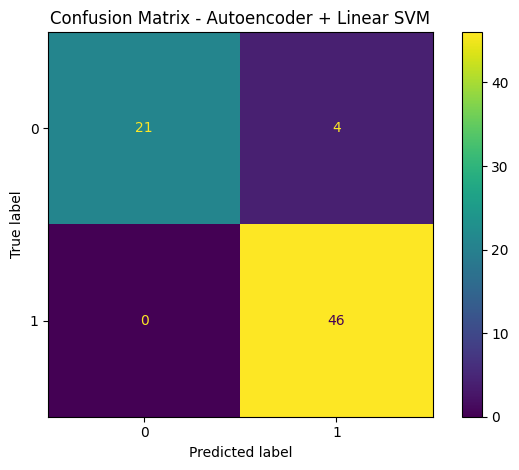

In [22]:
ae_svm = SVC(kernel="linear", random_state=42)
ae_results = evaluate_model(
    ae_svm,
    X_train_ae,
    X_test_ae,
    y_train,
    y_test,
    "Autoencoder + Linear SVM"
)

### Compare all results

In [23]:
all_results = pd.DataFrame([
    linear_results,
    rbf_results,
    pca_results,
    kpca_results,
    poly_results,
    ae_results
])

all_results = all_results.sort_values(by="F1", ascending=False).reset_index(drop=True)
print(all_results)

all_results.to_csv(f"{SAVE_DIR}/results/model_comparison.csv", index=False)

                              Model  Accuracy  Precision    Recall        F1
0           Kernel PCA + Linear SVM  0.971831   0.978261  0.978261  0.978261
1  Polynomial Features + Linear SVM  0.957746   0.938776  1.000000  0.968421
2                           RBF SVM  0.957746   0.957447  0.978261  0.967742
3          Autoencoder + Linear SVM  0.943662   0.920000  1.000000  0.958333
4                  PCA + Linear SVM  0.929577   0.901961  1.000000  0.948454
5                        Linear SVM  0.887324   0.895833  0.934783  0.914894


### Visualize the comparison

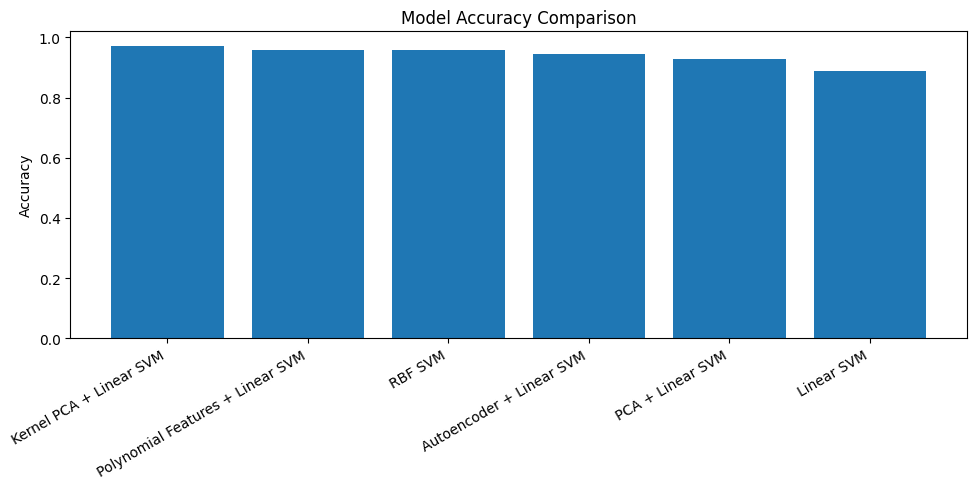

In [24]:
plt.figure(figsize=(10, 5))
plt.bar(all_results["Model"], all_results["Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/model_accuracy_comparison.png", dpi=300)
plt.show()

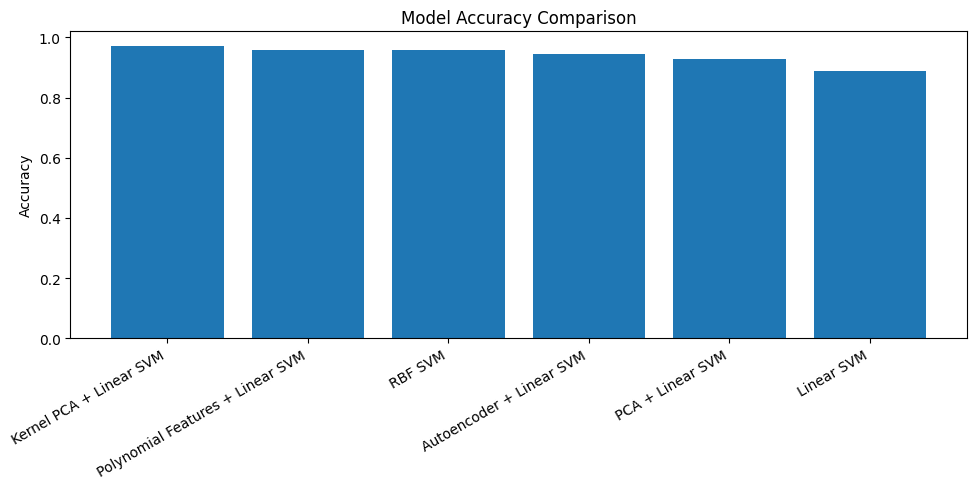

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(all_results["Model"], all_results["Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/model_accuracy_comparison.png", dpi=300)
plt.show()

### Visualize learned embeddings

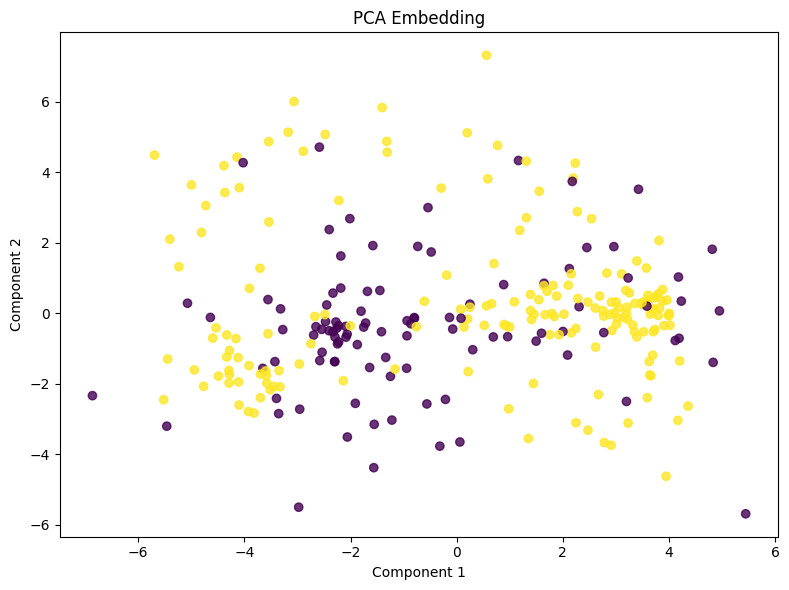

In [26]:
if X_train_pca.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, alpha=0.8)
    plt.title("PCA Embedding")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/figures/pca_embedding_scatter.png", dpi=300)
    plt.show()

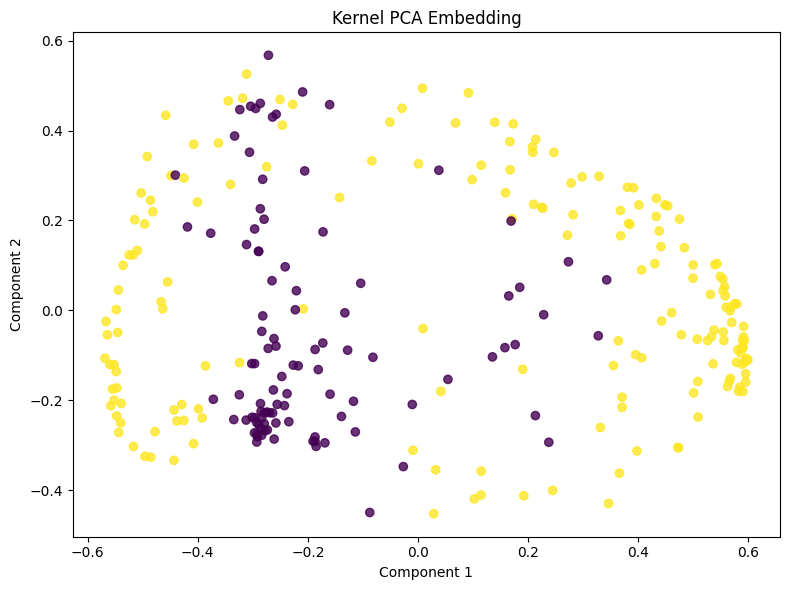

In [27]:
if X_train_kpca.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], c=y_train, alpha=0.8)
    plt.title("Kernel PCA Embedding")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/figures/kpca_embedding_scatter.png", dpi=300)
    plt.show()

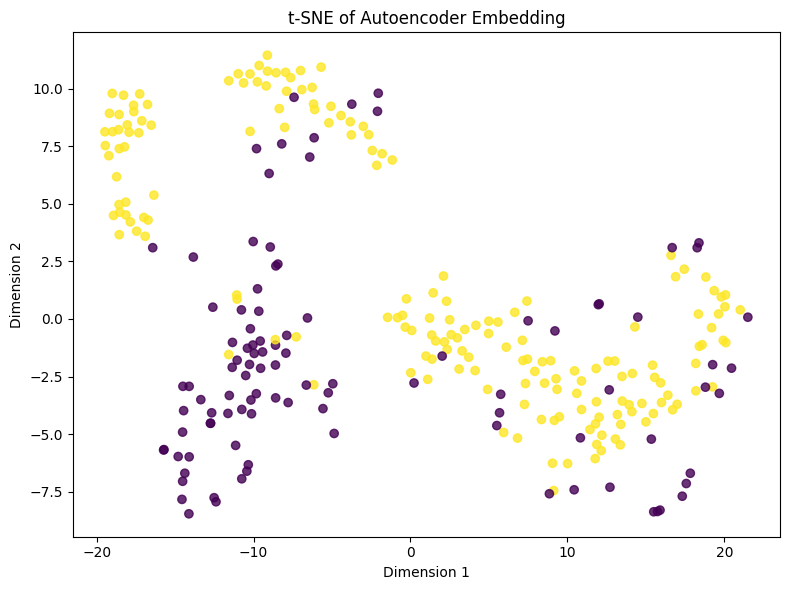

In [28]:
tsne_ae = TSNE(n_components=2, random_state=42, perplexity=30)
X_train_ae_tsne = tsne_ae.fit_transform(X_train_ae)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_ae_tsne[:, 0], X_train_ae_tsne[:, 1], c=y_train, alpha=0.8)
plt.title("t-SNE of Autoencoder Embedding")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/autoencoder_embedding_tsne.png", dpi=300)
plt.show()

In [29]:
best_model_row = all_results.iloc[0]

summary_text = f"""
Ionosphere Dataset Experiment Summary

Best model: {best_model_row['Model']}
Accuracy: {best_model_row['Accuracy']:.4f}
Precision: {best_model_row['Precision']:.4f}
Recall: {best_model_row['Recall']:.4f}
F1 Score: {best_model_row['F1']:.4f}

Interpretation:
- Linear SVM serves as the interpretable baseline.
- RBF SVM serves as the strong non-linear benchmark.
- PCA, Kernel PCA, Polynomial Features, and Autoencoder embeddings were tested
  to determine whether transformed representations can improve linear SVM.
- The comparison helps identify which embedding method best narrows the gap
  between linear and non-linear SVM performance.
"""

with open(f"{SAVE_DIR}/results/final_summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)


Ionosphere Dataset Experiment Summary

Best model: Kernel PCA + Linear SVM
Accuracy: 0.9718
Precision: 0.9783
Recall: 0.9783
F1 Score: 0.9783

Interpretation:
- Linear SVM serves as the interpretable baseline.
- RBF SVM serves as the strong non-linear benchmark.
- PCA, Kernel PCA, Polynomial Features, and Autoencoder embeddings were tested
  to determine whether transformed representations can improve linear SVM.
- The comparison helps identify which embedding method best narrows the gap
  between linear and non-linear SVM performance.



In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
